In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import scipy.io as sio
from dataclasses import dataclass
from typing import List, Tuple
import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
from stl import mesh
import matplotlib.pyplot as plt
import re

In [2]:
import sys
import os

# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(fr'H:\phd stuff\tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

In [3]:
tidy3dAPI = os.environ["API_TIDY3D_KEY"]


In [4]:
lambdas = np.array([8,2])

Processing directory: ./Structures
n_2.9275_ff_0.2172.h5
Configured successfully.
Exist!
Configured successfully.
Exist!
Configured successfully.
Exist!
Configured successfully.
Exist!
Configured successfully.
Exist!
Configured successfully.


11:22:32 W. Europe Daylight Time Created task                                   
                                 'LSU_ffr_0.2172_size_1.2237762237762237_n_2.93'
                                 with task_id                                   
                                 'fdve-f65e4474-1f38-46f0-8521-829c81210241' and
                                 task_type 'FDTD'.

                                 View task using web UI at                      
                                 ]8;id=946505;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=35270;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\task]8;;\
                                 ]8;id=35270;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\Id]8;;\]8;id=946505;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\=]8;;\]8;id=636820;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\fdve]8;;\]8;id=946505;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\-f65e4474-1f38-46f0-8521-829c81210241']8;;\.

                                 Task folder: ]8;id=862802;https://tidy3d.simulation.cloud/folders/folder-2b589a6c-2fc9-46b0-9353-e21e907219eb\'20260420 LSU Transmission ]8;;\       
                                 ]8;id=862802;https://tidy3d.simulation.cloud/folders/folder-2b589a6c-2fc9-46b0-9353-e21e907219eb\n_2.9275 ff_0.2172']8;;\.

Output()

11:23:18 W. Europe Daylight Time Maximum FlexCredit cost: 2.418. Minimum cost   
                                 depends on task execution details. Use         
                                 'web.real_cost(task_id)' to get the billed     
                                 FlexCredit cost after a simulation run.

<Figure size 1280x960 with 0 Axes>

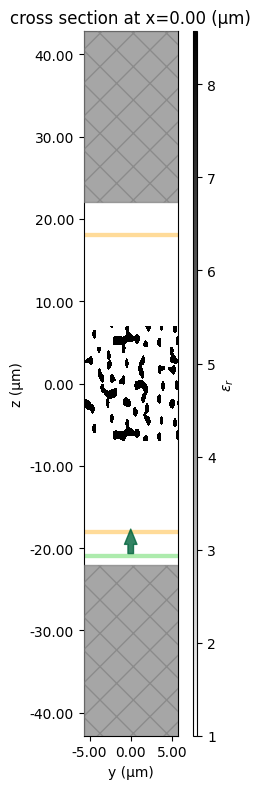

<Figure size 1600x1200 with 0 Axes>

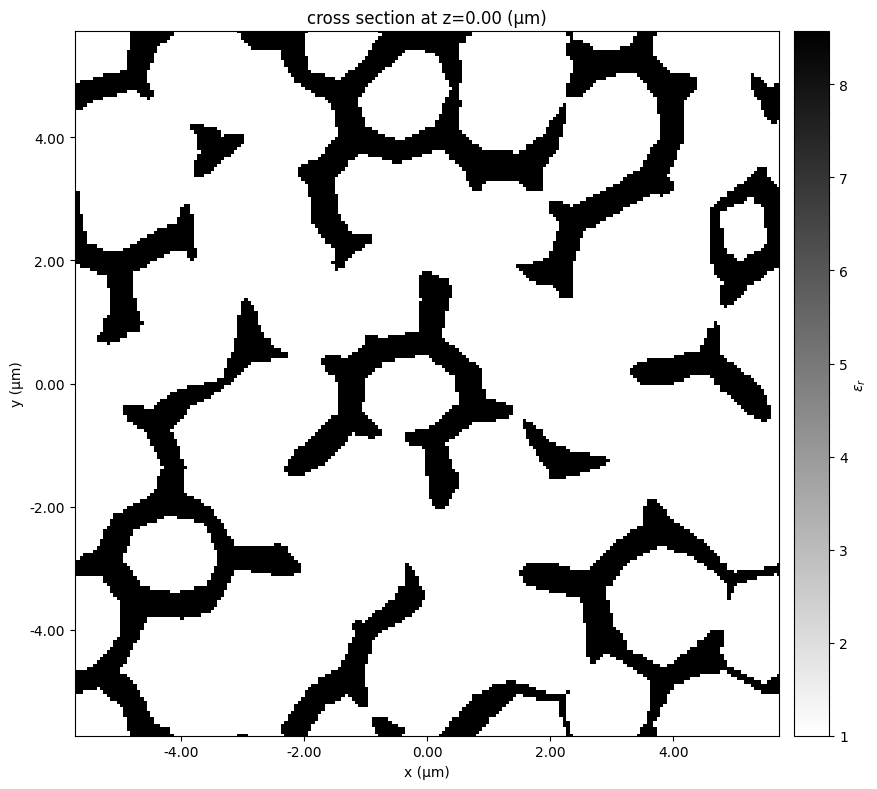

<Figure size 640x480 with 0 Axes>

11:23:29 W. Europe Daylight Time status = queued

                                 To cancel the simulation, use                  
                                 'web.abort(task_id)' or 'web.delete(task_id)'  
                                 or abort/delete the task in the web UI.        
                                 Terminating the Python script will not stop the
                                 job running on the cloud.

Output()

11:23:43 W. Europe Daylight Time status = preprocess

...

Output()

11:28:14 W. Europe Daylight Time status = postprocess

Output()

11:28:23 W. Europe Daylight Time status = success

11:28:25 W. Europe Daylight Time View simulation result at                      
                                 ]8;id=888994;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=6157;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\task]8;;\
                                 ]8;id=6157;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\Id]8;;\]8;id=888994;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\=]8;;\]8;id=902843;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\fdve]8;;\]8;id=888994;https://tidy3d.simulation.cloud/workbench?taskId=fdve-f65e4474-1f38-46f0-8521-829c81210241\-f65e4474-1f38-46f0-8521-829c81210241']8;;\.

In [5]:
folder_path = rf"./Structures"
project_name = "20260420 LSU Transmission n_2.9275 ff_0.2172"
postprocess_results = []
runtime_ps = 25e-12
min_steps_per_lambda = 20
h5_bg = None
ref = False
cuts=np.array([4,8,9,10,12,14])/11.44
for direction in ["z"]: 
    for dirpath, dirnames, filenames in os.walk(folder_path):
        print(f"Processing directory: {dirpath}")
        try:
            for filename in filenames:
                print(filename)
                if filename.endswith(".h5"):
                    n_value = float(re.search(r'n_([+-]?\d+(?:\.\d+)?)', filename).group(1))
                    ff = float(re.search(r'ff_([+-]?\d+(?:\.\d+)?)', filename).group(1))
                    for cut in cuts:
                        if not (Path(filename).suffix==".h5" or Path(filename).suffix==".stl"):
                            continue 
                        if os.path.isfile(os.path.join(dirpath, filename)):
                            file=os.path.join(dirpath, filename)
                            structure_1 = AM.loadAndRunStructure(key = tidy3dAPI, file_path=file
                                                            ,direction=direction, lambda_range=lambdas,
                                                            box_size=11.44,runtime_ps=runtime_ps,min_steps_per_lambda=min_steps_per_lambda,
                                                           scaling=1,shuoff_condtion=1e-20, verbose=True, 
                                                           monitors=["flux"], flux_monitor_position=18,cell_size_manual=44,
                                                           freqs=400, 
                                                           cut_condition=cut, source="planewave", absorbers=130, use_permittivity=False,sim_name=rf"{Path(filename).stem}_size_{cut}" + (rf"_bg_{h5_bg}" if h5_bg else ""),h5_bg=h5_bg,
                                                           )
                            folder_desc = rf"H:\phd stuff\tidy3d\data\{project_name}\n_{n_value:.2f}"
                            os.makedirs(folder_desc, exist_ok=True)
                            sim_name=rf"LSU_ffr_{ff}_size_{cut}_n_{n_value:.2f}"
                            
                            if os.path.exists(os.path.join(folder_desc, sim_name+".txt")):
                                print("Exist!")
                            else:
                                if ref:
                                 sim0=(structure_1.sim).copy(update={"structures":[]})
                                 id0 =web.upload(sim0, folder_name=project_name,task_name=sim_name+"_0", verbose=True)
                                 web.start(task_id = id0)
                                 web.monitor(task_id=id0,verbose=True)
                                 with open(os.path.join(folder_desc, "reference.txt"), "w") as file:
                                    # Write the string to the file
                                    file.write('\n'+id0)
                                 ref=False

                                id =web.upload(structure_1.sim, folder_name=project_name,task_name=sim_name, verbose=True)
                                structure_1.plot_sim_layout()
                                ids = '\n' + id
                                with open(os.path.join(folder_desc, sim_name+".txt"), "w") as file:
                                    # Write the string to the file
                                    file.write(ids)
                                web.start(task_id = id)
                                web.monitor(task_id=id,verbose=True)
                            del structure_1

        except Exception as e:
            print(f"Error processing {dirpath}: {e}")
            continue
        
    

        
    

